# Shape Detection 
by Eske and ELiot 




In [ ]:
# load all our functions etc 

# activate packages set environment 
using Pkg
Pkg.activate(".")
Pkg.instantiate()
Pkg.activate(".")
# include src files 
include("src/filtration.jl")
import .Filtration
include("src/preprocessing.jl")
import .Preprocessing
include("src/visualization.jl")
import .Visualization
include("src/persistence.jl")
import .Persistence


  Activating project at `c:\Users\Lukas\Desktop\TopologicalDataAnalysis\ShapeDetectionGit\Detecting-Shapes`
  0 dependencies successfully precompiled in 7 seconds. 282 already precompiled.
  1 dependency errored.
  For a report of the errors see `julia> err`. To retry use `pkg> precompile`
  Activating project at `c:\Users\Lukas\Desktop\TopologicalDataAnalysis\ShapeDetectionGit\Detecting-Shapes`


In [29]:
# add packages 
using Clustering
using StatsPlots
using LinearAlgebra
using PersistenceDiagrams
using Ripserer
using Plots

## Problem 
>Question: How can we distinguish/ detect different shapes? 

**What kind of shapes?**
Circle, Disk, Ellipsoid, Line Segment, Potato, Sphere, Torus ... 

- need pointclouds to display them in the computer 
- pointclouds should be in some sense normalized 

In [188]:
# Load pointclouds 
shapes = ["sphere", "torus", "line_segment", "disk", "potato", "ellipsoid"]
n_pershape = [1,2,3] 
n_datapoints = 200

# some oher less important settings 
path_changes = Dict("line_segment" => "line")
good_layout = (3,2)

# vector saving the loaded pointclouds 
pointclouds = []

# vector indicating to which shape each pointlcoud belongs to 
corr_results = []

# load the pointclouds from the data
for s in shapes 
    for i in n_pershape
        push!(corr_results, s*"_"*lpad(i,4,'0'))
        # load the data 
        if s in keys(path_changes) 
            path = "data\\"*s*"\\samples\\"*path_changes[s]*"_"*lpad(i,4,'0')*".csv"
        else 
            path = "data\\"*s*"\\samples\\"*s*"_"*lpad(i,4,'0')*".csv"
        end 
        println(path)
        df = Preprocessing.load_pointcloud_csv(path)
        if n_datapoints != "end"
            df = df[1:n_datapoints,:]
        end 
        push!(pointclouds, df)
    end 
end 

data\sphere\samples\sphere_0001.csv
data\sphere\samples\sphere_0002.csv
data\sphere\samples\sphere_0003.csv
data\torus\samples\torus_0001.csv
data\torus\samples\torus_0002.csv
data\torus\samples\torus_0003.csv
data\line_segment\samples\line_0001.csv
data\line_segment\samples\line_0002.csv
data\line_segment\samples\line_0003.csv
data\disk\samples\disk_0001.csv
data\disk\samples\disk_0002.csv
data\disk\samples\disk_0003.csv
data\potato\samples\potato_0001.csv
data\potato\samples\potato_0002.csv
data\potato\samples\potato_0003.csv
data\ellipsoid\samples\ellipsoid_0001.csv
data\ellipsoid\samples\ellipsoid_0002.csv
data\ellipsoid\samples\ellipsoid_0003.csv


In [189]:
pointclouds[1][1:10,:]

10×3 Matrix{Float64}:
 -0.803428  -3.22215  -4.58433
 -0.616222  -2.87716  -5.19776
  4.32522   -2.84412  -6.08901
 -0.447399  -1.56709  -3.88092
  0.656978  -4.72431  -6.034
  2.14374   -3.7774   -1.09108
 -0.505685  -2.03885  -3.02259
  2.71531   -1.14244  -1.88261
  2.50408   -5.23968  -1.91135
  4.06504   -1.78595  -5.8463

In [190]:
# center and normalize the pointclouds
for (i, S) in enumerate(pointclouds)
    S = Preprocessing.center_points(S)
    S = Preprocessing.normalize_scale(S) 
    # change the format from matrix to [(x1, y1, z1), (x2, y2,z2), ...]
    pointclouds[i] = [tuple(S[i, :]...) for i in axes(S, 1)]
end

In [191]:
pointclouds[1][1:10,:]

10×1 Matrix{Tuple{Float64, Float64, Float64}}:
 (-0.8524391475204852, -0.05980389919853887, -0.1958967170048325)
 (-0.7944356294002932, 0.04708679050997366, -0.3859598087846018)
 (0.7366106031845493, 0.057323204229266275, -0.6621044117494441)
 (-0.7421279269938815, 0.4529957659104685, 0.022048248409449283)
 (-0.39994993248745614, -0.5252322563912077, -0.6450582862402671)
 (0.06070592021463414, -0.23184196473263427, 0.8864457219959948)
 (-0.7601868650510611, 0.3068270764314875, 0.2879900084950109)
 (0.23780056583132253, 0.5845667508978053, 0.6411989584397467)
 (0.172351041105211, -0.6849132933418974, 0.6322928395372306)
 (0.6559981127611382, 0.38518335918153124, -0.5869014376308497)

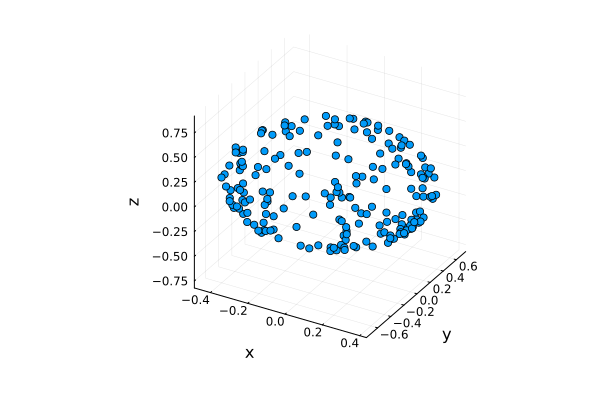

In [192]:
# visualize point cloud 
name = "ellipsoid_0001"
if !(name in corr_results)
    println("change the name to a loaded pointlcoud")
    println("- possible shapes: ", shapes)
    println("- possible numbers: ", n_pershape)
    println("name should be shape_00xx with xx changed to number")
else 
    idx = findfirst( ==(name), corr_results)
    display(Visualization.plot_pointcloud_3d(pointclouds[idx], check_npoints = false))
end 

>Question: How can we distinguish/ detect different shapes? 

**What kind of shapes?** 

        pointclouds ✔

**How to approximate the shapes in the computer?** 

- Some of the shapes are homotopy equivalent (Disk, Line, Potato are contractible, Ellipsoid h.e. to sphere)
- use persistent homology 
- need filtrations 
    - ~~Rips or Cech filtration~~ --> *very slow* :(
- use **Ripserer** to directly compute the persistence diagrams 
    `result = ripserer(S; dim_max = dim-1)`

In [194]:
# "Ripserer" indicates which filtration to use, false just avoids some print output
diagrams = Persistence.create_persistence_diagram(pointclouds, "Ripserer", false)

18-element Vector{Any}:
 PersistenceDiagram[200-element 0-dimensional PersistenceDiagram, 57-element 1-dimensional PersistenceDiagram, 2-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[200-element 0-dimensional PersistenceDiagram, 54-element 1-dimensional PersistenceDiagram, 2-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[200-element 0-dimensional PersistenceDiagram, 58-element 1-dimensional PersistenceDiagram, 1-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[200-element 0-dimensional PersistenceDiagram, 60-element 1-dimensional PersistenceDiagram, 27-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[200-element 0-dimensional PersistenceDiagram, 50-element 1-dimensional PersistenceDiagram, 27-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[200-element 0-dimensional PersistenceDiagram, 54-element 1-dimensional PersistenceDiagram, 25-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[200-element 0-dimension

For each pointlcoud, we have now three persistence diagrams, one for each dimension


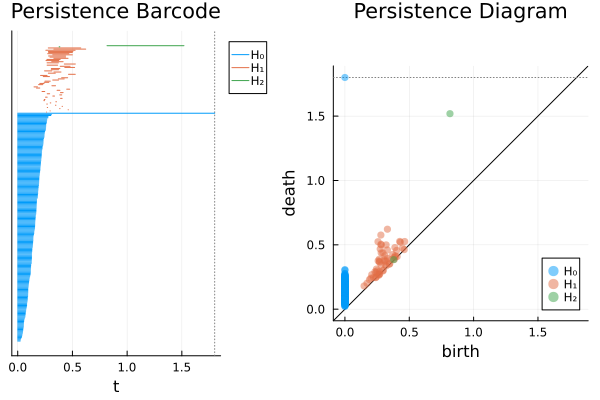

In [195]:
println("For each pointlcoud, we have now three persistence diagrams, one for each dimension")
diagrams[1]
display(plot( barcode(diagrams[1]), plot(diagrams[1])))

>Question: How can we distinguish/ detect different shapes? 

**What kind of shapes?** 

        pointclouds ✔

**How to approximate the shapes in the computer?** 
        
        Ripserer to compute persistence Diagrams ✔

**How to classify the different diagrams?** 

- Need some clustering on the diagrams
    - **Idea 1)** Use the Wasserstein distance on the persistence diagrams directly to perform clustering 
    - **Idea 2)** Convert the diagrams in a more useful datastructure and then perform clustering 

## Wasserstein Distance 
todo definition and stuff 


In [196]:
# compute the distance matrix for each dimension 
Ds = Persistence.create_wasserstein_matrix(diagrams)

3-element Vector{Matrix{Float64}}:
 [0.0 1.8267262420834065 … 7.682028778070838 7.512899767498371; 1.8267262420834065 0.0 … 6.3637609441355645 6.177784722040844; … ; 7.682028778070838 6.3637609441355645 … 0.0 0.8036470551117498; 7.512899767498371 6.177784722040844 … 0.8036470551117498 0.0]
 [0.0 1.102462768671015 … 2.142035574074863 1.9259400773369897; 1.102462768671015 0.0 … 2.1573162229620193 2.0430802044127363; … ; 2.142035574074863 2.1573162229620193 … 0.0 0.8584584456362818; 1.9259400773369897 2.0430802044127363 … 0.8584584456362818 0.0]
 [0.0 0.15790228290530206 … 0.5086440287518218 0.5130072133329837; 0.15790228290530206 0.0 … 0.5580186627339084 0.5623818473150703; … ; 0.5086440287518218 0.5580186627339084 … 0.0 0.012701690557714529; 0.5130072133329837 0.5623818473150703 … 0.012701690557714529 0.0]

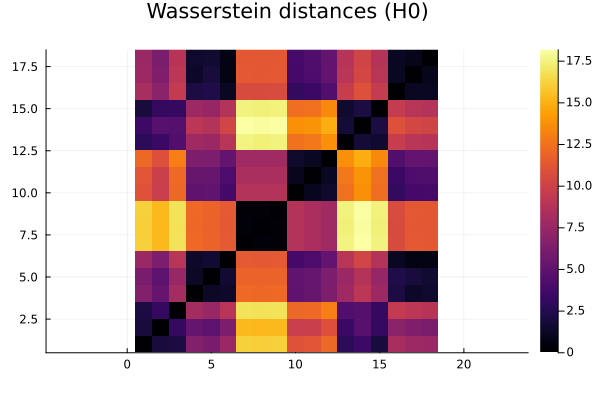

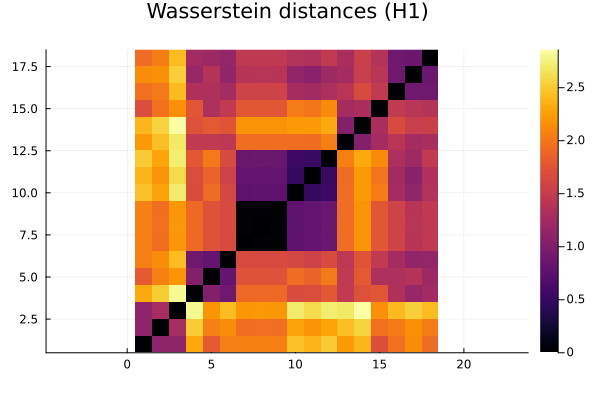

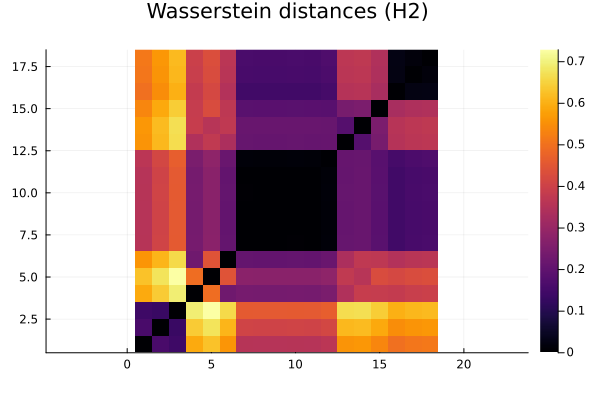

In [197]:
display(heatmap(Ds[1], aspect_ratio=:equal, title="Wasserstein distances (H0)"))
display(heatmap(Ds[2], aspect_ratio=:equal, title="Wasserstein distances (H1)"))
display(heatmap(Ds[3], aspect_ratio=:equal, title="Wasserstein distances (H2)"))

In [ ]:
# combine the different distance matrices 
weights = (0.5,3, 0.5)

n = size(Ds[1], 1)
# empty matrix of same size 
D = zeros(Float64, n, n)

# combine the different distance matrices using the weights 
for (hi, w) in enumerate(weights)
    D += w .* Ds[hi]
end 
display(heatmap(D, aspect_ratio=:equal, title="combined Wasserstein distances"))

In [ ]:
# clustering 

results_clustering = hclust(D; linkage=:average)
clusters = cutree(results_clustering; k = length(shapes))

for c in 1:length(shapes)
    println("Cluster $c ---------")
    println(corr_results[clusters.== c])
end


Cluster 1 ---------
Any["sphere_0001", "sphere_0002"]
Cluster 2 ---------
Any["sphere_0003"]
Cluster 3 ---------
Any["torus_0001", "torus_0002", "torus_0003", "ellipsoid_0001", "ellipsoid_0002", "ellipsoid_0003"]
Cluster 4 ---------
Any["line_segment_0001", "line_segment_0002", "line_segment_0003"]
Cluster 5 ---------
Any["disk_0001", "disk_0002", "disk_0003"]
Cluster 6 ---------
Any["potato_0001", "potato_0002", "potato_0003"]


### Persistence Silhuette 

persistence silhuette **summaries** the information of the persistence diagrams 

**Persistence diagram** →transformed to→     real valued function i.e. a **vector** = persistence silhuette

For each bar $[b_i, d_i)$ in the persistence diagram, we compute a weight 
$$ w_i := |d_i - b_i| $$
And a triangle function 
$$\Lambda_i(t) := \begin{cases} t-b & t \in [b, \frac{b+d}{2}) \\ d-t & t \in (\frac{b+d}{2}, d] \end{cases} $$
This combines in the silhoutte function 
$$\phi_i(t) := \frac{\sum_i w_i \Lambda_i}{\sum_i w_i}$$

>"Stochastic Convergence of Persistence Landscapes and Silhouettes", Chazal F. et al

1) Compute persistence silhuette for each dimension and pointcloud
2) For each pointcloud concatenate the silhuette functions 
3) Perform clustering on the obtaines vectors 
    - kmean
    - hclust

In [201]:
silhouettes_separatly = [[Persistence.persistence_silhoutte(d) for d in diags] for diags in diagrams] 

18-element Vector{Vector{Vector{Float64}}}:
 [[0.0, 0.003104588845760816, 0.006209177691521632, 0.009313766537282452, 0.012415570282750435, 0.015508101954954919, 0.01859112534291824, 0.021654612130129588, 0.024688698990464126, 0.02767112715893022  …  0.0005169006742020269, 0.00045403939501760906, 0.00039117811583319124, 0.0003283168366487734, 0.00026545555746435565, 0.0002025942782799378, 0.00013973299909552, 7.68717199111022e-5, 3.1681328309030444e-5, 0.0], [0.0, 3.644551064781997e-5, 7.289102129563972e-5, 0.0001093365319434597, 9.306793176049105e-5, 6.800541076778003e-5, 6.658990274152004e-5, 8.144299489822869e-5, 0.0001041838754886273, 7.965636859537007e-5  …  0.0030541794710390487, 0.002714826196479155, 0.002375472921919262, 0.0020361196473593682, 0.0016967663727994748, 0.0013574130982395814, 0.0010180598236796802, 0.0006787065491197868, 0.0003393532745598934, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.10278825655875161, 0.09136733916333487, 0.07994642176791789, 

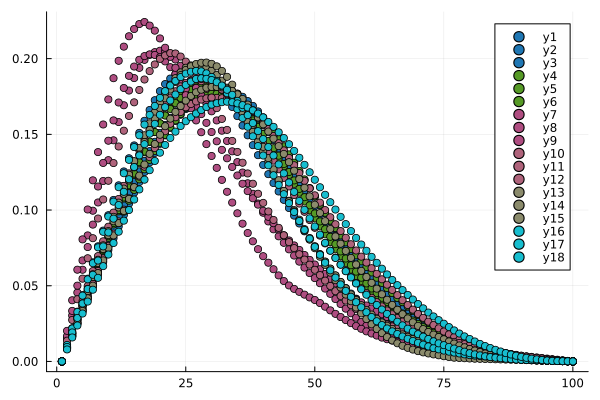

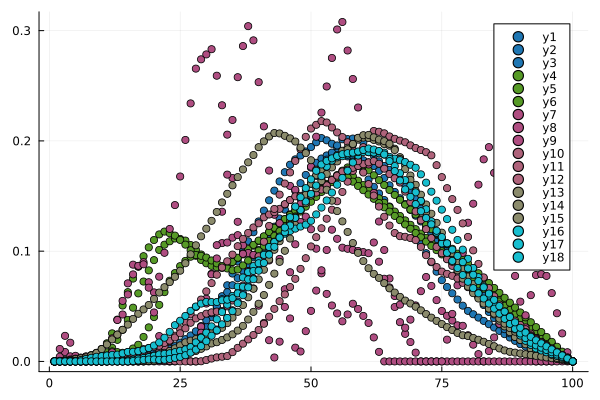

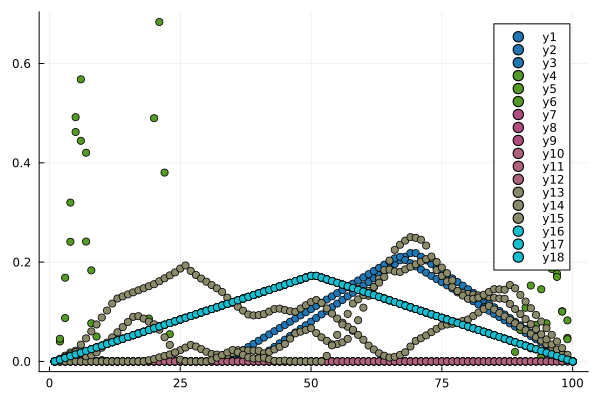

In [ ]:
# plot all persistence silhouettes together coloured by their shape 
shape_colors = palette(:tab10, length(shapes)) 

plots = []
for i in 1:length(silhouettes_separatly[1])
    pl = plot()
    for sil_idx in 1:length(corr_results)
        sil = silhouettes_separatly[sil_idx][i]
        
        # normalize
        if norm(sil) != 0 
            sil = sil ./ norm(sil)
        end

        # shape of the pointcloud
        sp = join(split(corr_results[sil_idx], "_")[1:end-1], "_")
        
        # get index of the shape in shapes 
        sp_idx =  findfirst( ==(sp), shapes)
        scatter!(pl, 1:length(sil), sil; color = shape_colors[sp_idx],label= corr_results[sil_idx])
    end 
    push!(plots, pl)
end 

for pl in plots
    display(pl)
end 


In [206]:
weights = (0.1,0.45, 0.45)
silhouettes = [Persistence.concatenate_silhouette(s, weights) for s in silhouettes_separatly] 

18-element Vector{Vector{Any}}:
 [0.0, 0.00031045888457608166, 0.0006209177691521633, 0.0009313766537282453, 0.0012415570282750437, 0.0015508101954954919, 0.001859112534291824, 0.002165461213012959, 0.0024688698990464127, 0.0027671127158930223  …  0.04625471545143822, 0.04111530262350069, 0.03597588979556305, 0.030836476967625516, 0.025697064139687878, 0.020557651311750344, 0.015418238483812708, 0.010278825655875172, 0.0051394128279375366, 0.0]
 [0.0, 0.0003605820741158372, 0.0007211641482316744, 0.0010814889175695876, 0.0014402372549227862, 0.0017977230854481297, 0.0021538076214638884, 0.002501848005932856, 0.0028430328927457624, 0.003177556492967773  …  0.04841566351078103, 0.04303614534291649, 0.03765662717505187, 0.032277109007187325, 0.026897590839322784, 0.021518072671458246, 0.01613855450359371, 0.010759036335729074, 0.005379518167864537, 0.0]
 [0.0, 0.00035785809039378107, 0.0007157161807875621, 0.0010732358988570167, 0.0014299510746863886, 0.001784348783423988, 0.0021364956808

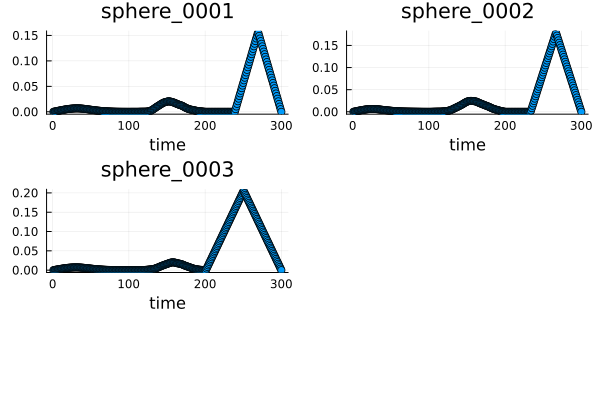

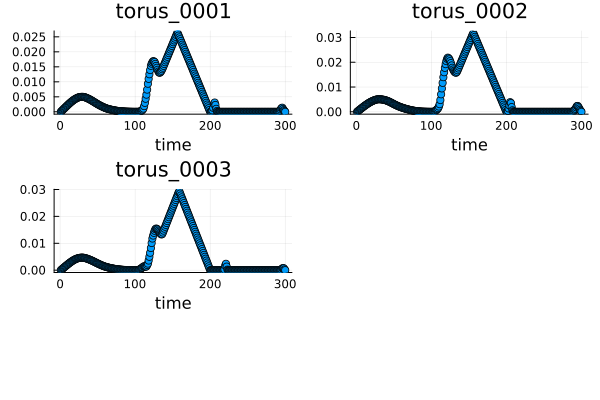

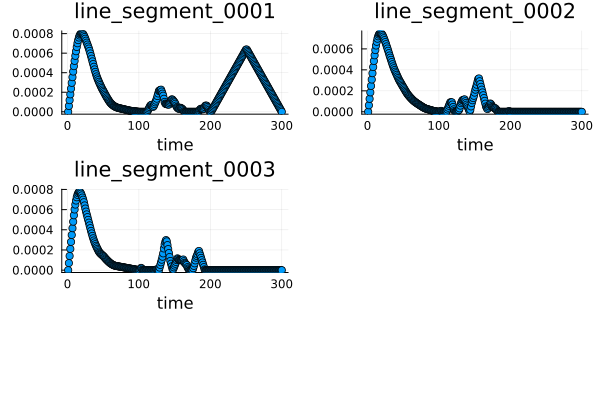

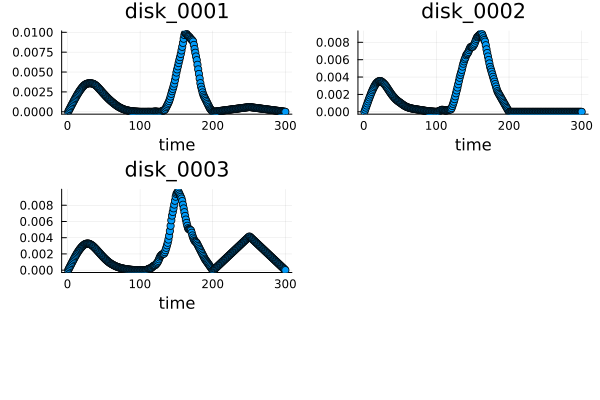

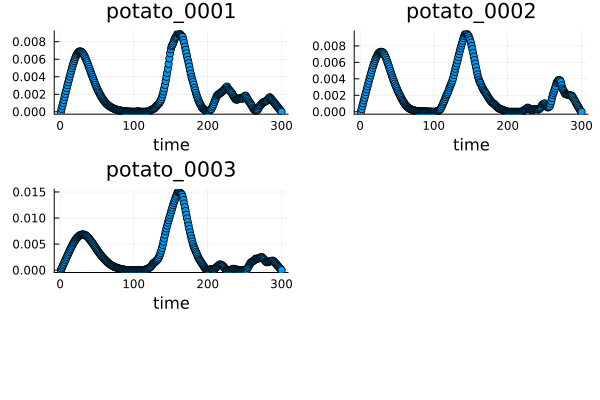

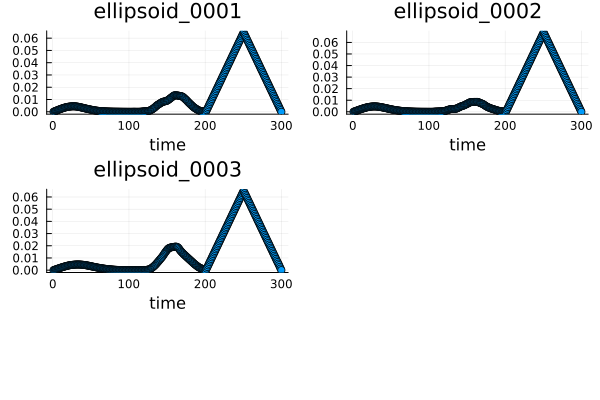

In [207]:
plots = []

for (i,sil) in enumerate(silhouettes) 
    ttl = corr_results[i]
    push!(plots,Visualization.plot_persistence_silhouette_approx(sil; ttl = ttl))
    if i%length(n_pershape) == 0
        display(plot(plots[(i-length(n_pershape)+1):i]..., layout = good_layout))
    end
end 

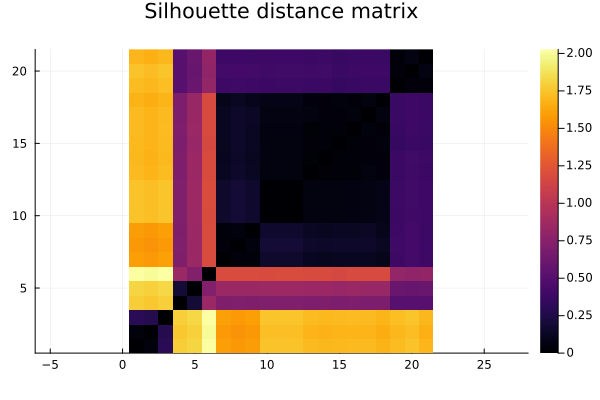

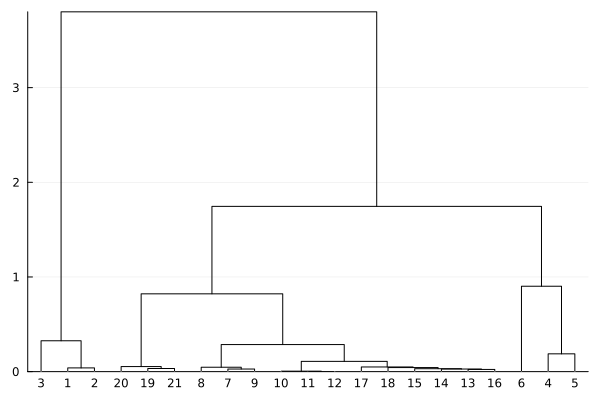

Cluster 1 ---------
Any["circle_0001", "circle_0002"]
Cluster 2 ---------
Any["circle_0003"]
Cluster 3 ---------
Any["sphere_0001", "sphere_0002"]
Cluster 4 ---------
Any["sphere_0003"]
Cluster 5 ---------
Any["torus_0001", "torus_0002", "torus_0003"]
Cluster 6 ---------
Any["line_segment_0001", "line_segment_0002", "line_segment_0003", "disk_0001", "disk_0002", "disk_0003", "potato_0001", "potato_0002", "potato_0003"]
Cluster 7 ---------
Any["ellipsoid_0001", "ellipsoid_0002", "ellipsoid_0003"]


In [ ]:
# hirachical clustering 
normalize = false 

# prepare the data - normalization 
Xh = []
for sil in silhouettes
    if normalize 
        push!(Xh, sil ./ norm(sil))
    else 
        push!(Xh, sil)
    end 
end   

# create distance matrix 
D_sil = zeros(length(Xh), length(Xh))
for (i, sil) in enumerate(Xh) 
    for j in 1:i-1
        D_sil[i,j] = norm(sil - Xh[j])
        D_sil[j,i] = norm(sil - Xh[j])
    end 
end 

display(heatmap(D_sil, aspect_ratio=:equal, title="Silhouette distance matrix"))

# perform hirachical clustering 
results_hclustering_sil =  hclust(D_sil, linkage = :ward)
display(plot(results_hclustering_sil))

# get clusters
# k = number of clusters 
hclusters_sil = cutree(results_hclustering_sil; k = length(shapes))

# print results 
for c in 1:length(shapes)
    println("Cluster $c ---------")
    println(corr_results[hclusters_sil .== c])
end

In [ ]:
# kmeans clustering 
normalize = true 

# prepare the data 
Xk = [Vector{Float64}(s) for s in silhouettes]
Xk = hcat(Xk...)
for i in 1:size(Xk)[2]
    # normalize each col
    if normalize && (norm(Xk[:,i]) != 0)
        Xk[:,i] = Xk[:,i] ./ norm(Xk[:,i])
    end 
end 

# perform kmeans clustering 
results_kclustering_sil = kmeans(Xk, length(shapes))

# get the clusters 
kclusters_sil = results_kclustering_sil.assignments

# print the results 
for c in 1:length(shapes)
    println("Cluster $c ---------")
    println(corr_results[kclusters_sil .== c])
end


Cluster 1 ---------
Any["line_segment_0001"]
Cluster 2 ---------
Any["potato_0002"]
Cluster 3 ---------
Any["sphere_0001", "sphere_0002", "sphere_0003", "ellipsoid_0001", "ellipsoid_0002", "ellipsoid_0003"]
Cluster 4 ---------
Any["circle_0001", "circle_0002", "circle_0003", "torus_0001", "torus_0002", "torus_0003", "disk_0002"]
Cluster 5 ---------
Any["disk_0001", "potato_0001", "potato_0003"]
Cluster 6 ---------
Any["line_segment_0002", "line_segment_0003"]
Cluster 7 ---------
Any["disk_0003"]


# additional ideas ... (not presented)

In [ ]:
# hirachical clustering on the seperate silhuettes 

# create distance matrix
D_sil_3 = zeros(length(silhouettes_separatly), length(silhouettes_separatly))
for (i, sil_i) in enumerate(silhouettes_separatly) 
    for j in 1:i-1
        sil_j = silhouettes_separatly[j]
        v = [abs.(sil_i[hi] .- sil_j[hi])  for hi in 1:length(sil_i)]
        d = maximum(maximum(reduce(vcat, permutedims.(v)), dims = 1))
        D_sil_3[i,j] = d
        D_sil_3[j,i] = d
    end 
end

display(heatmap(D_sil_3, aspect_ratio=:equal, title="Silhouette distance matrix"))

# perform hirachical clustering 
results_hclustering_sil_3 =  hclust(D_sil_3, linkage = :ward)
display(plot(results_hclustering_sil_3))

# get clusters
# k = number of clusters 
hclusters_sil_3 = cutree(results_hclustering_sil_3; k = length(shapes))

# print results 
for c in 1:length(shapes)
    println("Cluster $c ---------")
    println(corr_results[hclusters_sil_3 .== c])
end